This notebook trains and evaluates an injury prediction model using the features computed in notebook 03.
                                                                                                           
  Models:                                                                                                  
  - Logistic Regression (primary)                                                                        
  - Random Forest (comparison)

  Target: `injury_flag` — 1 if a player missed 10+ games, 0 otherwise

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                            recall_score, f1_score, roc_auc_score,
                            confusion_matrix, RocCurveDisplay)

## Loading features into database

In [3]:
base_dir = os.path.abspath('..')                                                                         
db_path = os.path.join(base_dir, 'database', 'nba_predictor.db')                                         
                                                                                                        
conn = sqlite3.connect(db_path)                                                                          
df = pd.read_sql_query("""                                                                             
    SELECT psf.player_id, psf.season, psf.workload_score, psf.per_change,
            psf.injury_flag, psf.age, psf.games_missed_last_season,
            ps.points_per_game, ps.minutes_per_game, ps.games_played
    FROM player_season_features psf
    JOIN player_stats ps ON psf.player_id = ps.player_id AND psf.season = ps.season
""", conn)
conn.close()

df = df.dropna()
print(f'Rows available for training: {len(df)}')
df.head()

Rows available for training: 4


,player_id,season,workload_score,per_change,injury_flag,age,games_missed_last_season,points_per_game,minutes_per_game,games_played
0,1,2022-23,0.853659,0.032773,1,38,20,25.0,35.0,70
1,2,2022-23,0.627178,-0.133333,0,31,0,20.0,30.0,60
2,1,2021-22,0.878049,0.031729,1,37,0,24.0,34.0,72
3,2,2021-22,0.652798,0.029630,0,30,0,22.0,28.0,65


In [4]:
X = df[['workload_score', 'per_change', 'age', 'games_missed_last_season',                             
        'points_per_game', 'minutes_per_game', 'games_played']]
y = df['injury_flag']

print(f'Features shape: {X.shape}')
print(f'Injury flag distribution:\n{y.value_counts()}')

Features shape: (4, 7)
Injury flag distribution:
injury_flag
1    2
0    2
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y                                                     
)                                                                                                      

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training rows: {len(X_train)}')
print(f'Test rows: {len(X_test)}')

Training rows: 2
Test rows: 2


In [7]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)                         
lr.fit(X_train_scaled, y_train)                                                                          
                                                                                                        
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train_scaled, y_train)

print('Models trained.')

Models trained.


## Evaluate Models

In [8]:
def evaluate_model(name, model, X_test, y_test):                                                         
    y_pred = model.predict(X_test)                                                                       
    y_prob = model.predict_proba(X_test)[:, 1]                                                         

    print(f'--- {name} ---')
    print(f'Accuracy:  {accuracy_score(y_test, y_pred):.2f}')
    print(f'Precision: {precision_score(y_test, y_pred, zero_division=0):.2f}')
    print(f'Recall:    {recall_score(y_test, y_pred, zero_division=0):.2f}')
    print(f'F1:        {f1_score(y_test, y_pred, zero_division=0):.2f}')
    print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob):.2f}')
    print()
    return y_pred

lr_preds = evaluate_model('Logistic Regression', lr, X_test_scaled, y_test)
rf_preds = evaluate_model('Random Forest', rf, X_test_scaled, y_test)

--- Logistic Regression ---
Accuracy:  1.00
Precision: 1.00
Recall:    1.00
F1:        1.00
ROC-AUC:   1.00

--- Random Forest ---
Accuracy:  1.00
Precision: 1.00
Recall:    1.00
F1:        1.00
ROC-AUC:   1.00



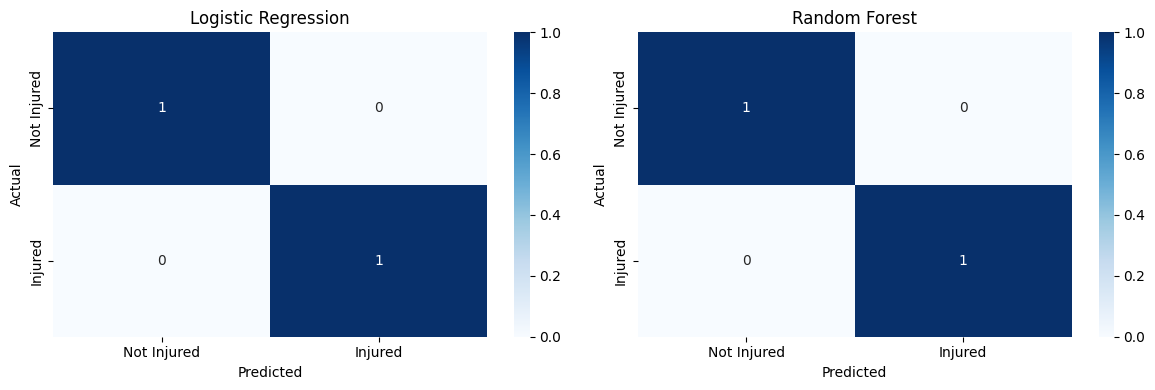

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, name in zip(axes, [lr_preds, rf_preds], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Injured', 'Injured'],
                yticklabels=['Not Injured', 'Injured'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

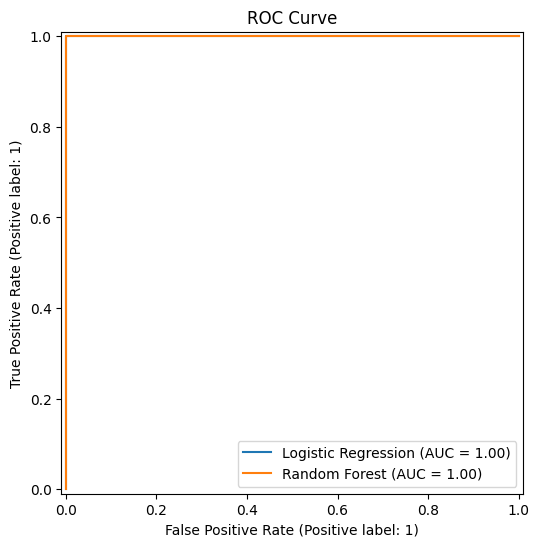

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(rf, X_test_scaled, y_test, ax=ax, name='Random Forest')

ax.set_title('ROC Curve')
plt.show()

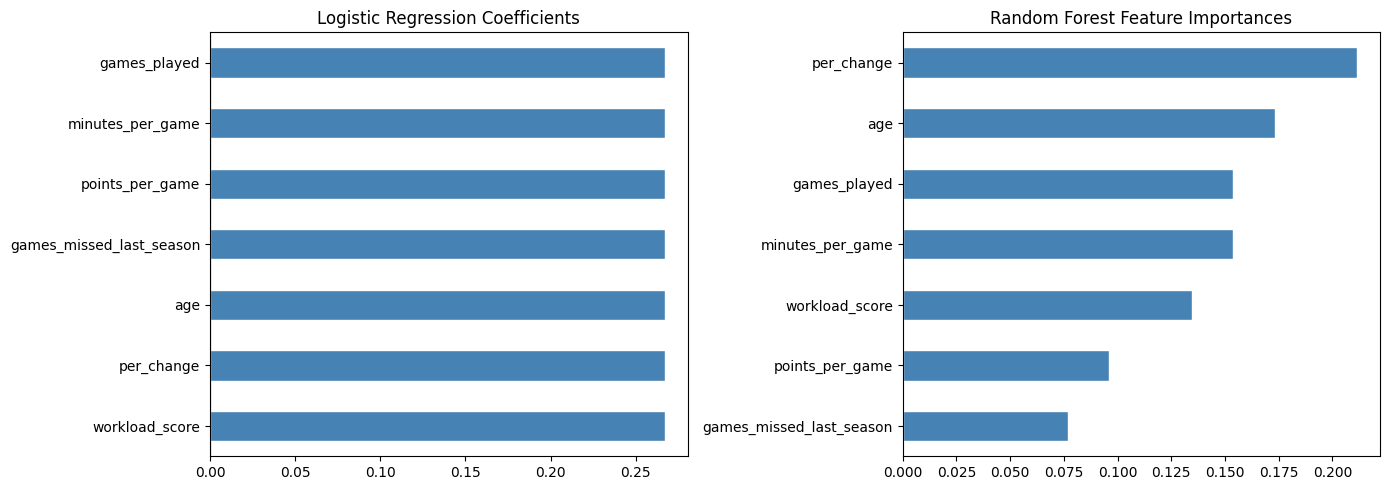

In [11]:
feature_names = X.columns.tolist()                                                                       
                                                                                                        
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                                        

# Logistic Regression coefficients
lr_coefs = pd.Series(lr.coef_[0], index=feature_names).sort_values()
lr_coefs.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Logistic Regression Coefficients')
axes[0].axvline(0, color='black', linewidth=0.8)

# Random Forest feature importances
rf_importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values()
rf_importances.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Random Forest Feature Importances')

plt.tight_layout()
plt.show()
